<img src="../../figs/holberton_logo.png" alt="logo" width="500"/>

# Transfer Learning Applications on Cifar - 10 Dataset

## Executive Summary

The **CIFAR-10** dataset is a widely used benchmark for image classification tasks. It consists of `60,000` `32x32` color images in `10` classes, with `6,000` images per class. **The classes include airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, and trucks**. 

The images are low-resolution and can be challenging to classify due to their small size and variability in appearance. The dataset is commonly used to evaluate the performance of image classification algorithms, including deep learning models.

## Setting up: Loading CIFAR-10

The `CIFAR-10` dataset consists of `60,000 32x32` **color** images in `10` classes, with `6,000` images per class. The dataset is split into two subsets: 
- a training set of `50,000` images
- a testing set of `10,000` images

The libraries loaded, including `TensorFlow` and `Keras`, provide essential tools and functions for building and training neural network models efficiently. Specifically, `TensorFlow` serves as the foundational framework for constructing computational graphs and executing machine learning operations, while `Keras` offers a high-level API that simplifies the process of building and training neural networks.

In [1]:
import tensorflow as tf
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.applications.resnet50 import preprocess_input
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Input, UpSampling2D, Flatten
from keras.optimizers import SGD
from keras.callbacks import EarlyStopping


The subsequent step involves loading the `CIFAR-10` dataset using Keras' built-in `cifar10.load_data()` function. This dataset consists of `60,000` `32x32` color images in `10` classes, with `6,000` images per class. The images are split into `50,000` training samples and `10,000` test samples. After loading the dataset, the pixel values are convereted to floating-point numbers.

In [2]:
# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print(f"Training data shape: {x_train_full.shape}")
print(f"Test data shape: {x_test.shape}")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


## Visualizing the dataset

The Cifar-10 dataset contains `10` classes, each corresponding to a different article of clothing:

| Label | Class Category |
|-------|----------------|
| 0     | airplane       |
| 1     | automobile     |
| 2     | bird           |
| 3     | cat            |
| 4     | deer           |
| 5     | dog            |
| 6     | frog           |
| 7     | horse          |
| 8     | ship           |
| 9     | truck          |

These classes can be **challenging to classify** due to several factors, including 

- the variability in appearance within each class 

- the presence of similar-looking objects across different classes

- variations in orientation, lighting conditions, and background clutter

- relatively low resolution (32x32 pixels) 



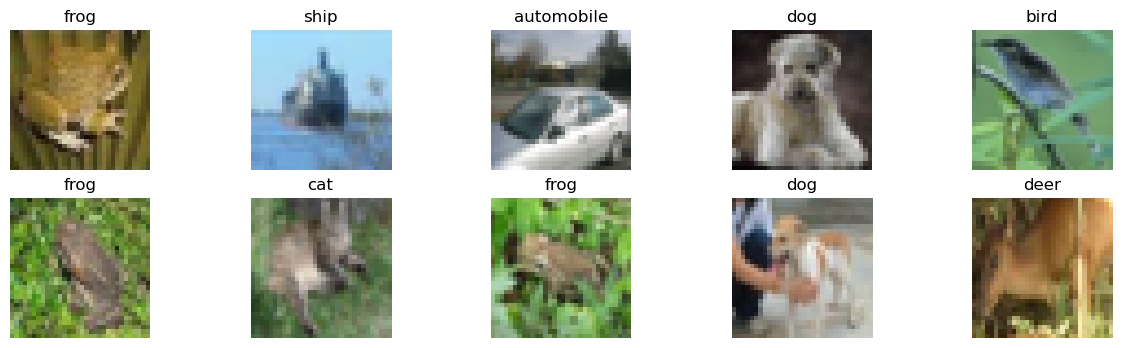

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define the class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Visualize random images from the dataset
plt.figure(figsize=(15, 4))
for i in range(10):
    idx = np.random.randint(0, len(x_train_full))
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train_full[idx])
    plt.title(class_names[y_train_full[idx][0]])
    plt.axis('off')
plt.show()

## Preprocessing Input Data for Pre-trained Models

In this step, we preprocess the input data using the `preprocess_input` function. This function is essential when working with pre-trained convolutional neural network (CNN) models like `ResNet50`, `VGG16`, or `InceptionV3`. **Preprocessing ensures that our input images are formatted correctly and normalized before being fed into the neural network for training or inference**.

Key functionalities of `preprocess_input`:

- Standardizes input data to a format expected by pre-trained CNN models.
- Typically performs mean normalization and channel-wise color normalization.
- Scales and centers input images appropriately, aiding in better convergence during training and improved accuracy during inference.
- Helps maintain numerical stability, preventing issues like vanishing or exploding gradients.
- Enhances the model's generalization capabilities by ensuring consistent and standardized input data.






In [4]:
x_train_full = x_train_full.astype('float32')
x_test = x_test.astype('float32')

# Preprocess the data using the preprocess_input function
x_train_full = preprocess_input(x_train_full)
x_test = preprocess_input(x_test)

print(f"Training data shape: {x_train_full.shape}")
print(f"Test data shape: {x_test.shape}")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


## Splitting and Categorizing Training and Validation Data

In this step, we divide the training set into separate training and validation sets using slicing operations. The training set, x_train_full, is split into two parts: 

- `x_train` containing the majority of the data 
- `x_valid` containing a smaller portion (5000 samples in this case) which will be used for validation during model training. 

Similarly, the corresponding labels are also split into `y_train` and `y_valid`. 

Additionally, we **convert the class labels from integer format to categorical format** using the `to_categorical` function. This is necessary for categorical classification tasks like CIFAR-10, where each image is assigned one of ten possible categories. 

Converting the labels to categorical format ensures that they are represented as **one-hot vectors**, which is required by the model during training and evaluation.

In [5]:
# Split the training set into training and validation sets
x_train, x_valid = x_train_full[:-5000], x_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Convert labels to categorical
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}, {y_train.shape}")
print(f"Validation data shape: {x_valid.shape}, {y_valid.shape}")
print(f"Test data shape: {x_test.shape}, {y_test.shape}")


Training data shape: (45000, 32, 32, 3), (45000, 10)
Validation data shape: (5000, 32, 32, 3), (5000, 10)
Test data shape: (10000, 32, 32, 3), (10000, 10)


## Defining Feature Extraction with ResNet50

In this step, we define a feature extractor using the `ResNet50` model, a pre-trained convolutional neural network (CNN) architecture. The **purpose of a feature extractor is to leverage the learned representations from a pre-trained model to extract relevant features from input images**. Here, we use `ResNet50`, a powerful and widely used CNN model pre-trained on the `ImageNet` dataset, which contains millions of images across thousands of categories.

The `feature_extractor` function **takes input tensors representing images and returns the output feature maps** generated by the `ResNet50` model. By setting `include_top=False`, we exclude the fully connected layers at the top of the `ResNet50` architecture, retaining only the convolutional layers. This allows us to **use `ResNet50` as a feature extractor while excluding its classification layers**, which are specific to the `ImageNet` task.

Additionally, we freeze the layers of the base `ResNet50` model by setting `layer.trainable = False` for each layer. **Freezing the layers prevents their weights from being updated during training**, ensuring that only the weights of the additional layers we add on top of the base model will be trained. 

This approach is common in transfer learning scenarios, where we aim to leverage pre-trained models to extract useful features for a different task without modifying the learned representations in the base model

In [6]:
# Define the feature extractor using ResNet50
def feature_extractor(inputs):
    base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3),
                                                include_top=False,
                                                weights='imagenet')
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    return base_model(inputs)

## Defining the Classifier
In this step, we define a classifier function that builds the classification layers on top of the features extracted by the `ResNet50` model. The classifier is responsible for mapping the extracted features to the corresponding class probabilities for the given task.

The classifier function **takes the output feature maps from the feature extractor as input and adds several dense layers to perform classification**. First, we *apply a global average pooling layer to reduce the spatial dimensions of the feature maps while retaining important spatial information*. Then, we flatten the pooled feature maps into a `1D` vector to feed into the fully connected layers.

Next, **we add two densely connected layers with `ReLU` activation functions**, which introduce non-linearity to the model and allow it to learn complex patterns in the data. These layers progressively reduce the dimensionality of the feature space, capturing increasingly abstract representations of the input data.

Finally, **we add a dense output layer with `softmax` activation**, consisting of `10` units corresponding to the `10` classes in the `CIFAR-10` dataset. The softmax function normalizes the output probabilities, ensuring that they sum up to 1 and represent the predicted probabilities for each class. The name "classification" is assigned to this layer for easy identification

In [7]:
# Define the classifier
def classifier(inputs):
    x = GlobalAveragePooling2D()(inputs)
    x = Flatten()(x)
    x = Dense(1024, activation="relu")(x)
    x = Dense(512, activation="relu")(x)
    x = Dense(10, activation="softmax", name="classification")(x)
    return x

## Defining the Final Model
In this step, we define the final model by integrating the feature extraction and classification components. The final model takes input tensors representing images and produces output predictions for the given task.

The `final_model` function begins by **upsampling the input images using the `UpSampling2D` layer**. This step increases the spatial dimensions of the images to match the input size expected by the `ResNet50` model. By resizing the images to a size of `(224, 224)`, we ensure compatibility with the input shape required by the pre-trained `ResNet50` architecture.

Next, **the resized images are passed through the feature extractor**, which extracts relevant features from the input images using the pre-trained `ResNet50` model. The feature extractor leverages the learned representations from the `ResNet50` architecture to capture meaningful patterns and characteristics present in the images.

**The extracted features are then fed into the classifier**, which consists of several densely connected layers followed by a softmax output layer. The classifier processes the extracted features and generates class probabilities for each input image, indicating the likelihood of belonging to each of the predefined classes.


In [8]:
# Define the final model
def final_model(inputs):
    resize = UpSampling2D(size=(7, 7))(inputs)
    resnet_feature_extractor = feature_extractor(resize)
    classification_output = classifier(resnet_feature_extractor)
    return classification_output


## Defining and Compiling the Model
In this step, we **define and compile the overall model architecture by integrating the feature extraction, classification, and input layers**. The defined model takes input tensors of shape `(32, 32, 3)`, representing the dimensions of the `CIFAR-10` images, and produces output predictions for the given task.

The `define_compile_model` function starts by creating an input layer with the specified shape of `(32, 32, 3)`, indicating the dimensions of the input images. This input layer serves as the entry point for the data into the model architecture.

Next, the final_model function is called to build the main body of the model, incorporating the feature extraction and classification components. The `final_model` function returns the output tensor representing the class predictions for the input images.

Subsequently, the overall model is constructed using the Model class, specifying the input and output tensors. This step effectively combines the input layer, feature extraction, and classification layers into a single cohesive model architecture.

In [9]:
from keras.optimizers import Adam

def define_compile_model():
    inputs = Input(shape=(32, 32, 3))
    classification_output = final_model(inputs) 
    model = Model(inputs=inputs, outputs=classification_output)
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


## Creating and Summarizing the Model

In this step, we create the neural network model, which defines the model architecture and compiles it with specified optimization parameters, loss function, and evaluation metrics. Once the model is created, we use the summary method to print a concise summary of its architecture. This summary provides key information about the model's structure, including the type and shape of each layer, the number of parameters, and the output shape of each layer. 

In [10]:
# Create the model
model = define_compile_model()

# Print the model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 up_sampling2d (UpSampling2  (None, 224, 224, 3)       0         
 D)                                                              
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 1024)              209817

## Training the Model with Early Stopping

Here, we employ the early stopping technique by defining an early stopping callback, which monitors the validation loss during training and halts the training process if the validation loss does not improve for a specified number of epochs (patience). The `restore_best_weights=True` argument ensures that the model's weights are reverted to the configuration yielding the lowest validation loss when training concludes.

In [11]:
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_valid, y_valid), callbacks=[early_stopping])

Epoch 1/20
1407/1407 [==============================] - 4973s 4s/step - loss: 0.7256 - accuracy: 0.7502 - val_loss: 0.5855 - val_accuracy: 0.7920
Epoch 2/20
1407/1407 [==============================] - 11733s 8s/step - loss: 0.5295 - accuracy: 0.8152 - val_loss: 0.5662 - val_accuracy: 0.8008
Epoch 3/20
 717/1407 [==============>...............] - ETA: 25:53 - loss: 0.4526 - accuracy: 0.8394

KeyboardInterrupt: 